
# **Scenario 1 – Clustering using K-Means**

## **Name:** SaiSanjay R
## **Roll.No:** 24BAD102

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

## 2. Load Dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Select Relevant Features

In [3]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

## 4. Data Preprocessing and Scaling

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 5. Elbow Method to Determine Optimal K

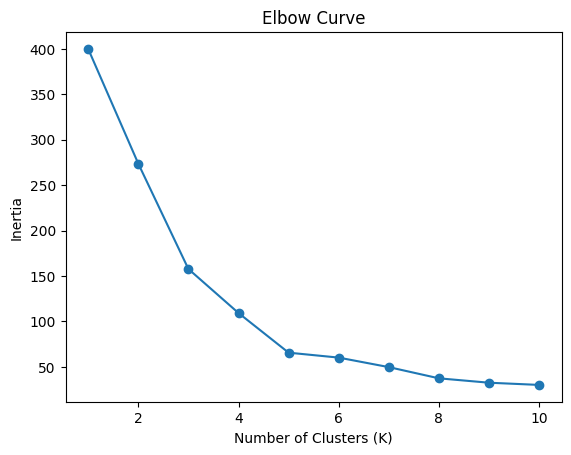

In [5]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Curve")
plt.show()

## 6. Apply K-Means Clustering

In [6]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

## 7. Assign Cluster Labels

In [7]:
df['Cluster'] = clusters
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## 8. Evaluation Metrics

In [8]:
print("Inertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_scaled, clusters))

Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091


## 9. Cluster Visualization

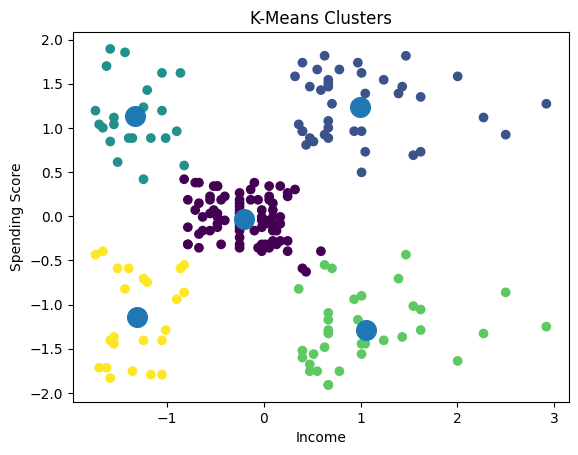

In [9]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=200)
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clusters")
plt.show()

## 10. Cluster Interpretation

In [11]:
df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043
